<a href="https://colab.research.google.com/github/qstnimn/DSP/blob/main/ForecastSIv2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

malaysia_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/malaysia-solar.csv')
thailand_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/thailand-solar.csv')

In [ ]:
# Display basic information
print("Malaysia Data Info:")
print(malaysia_data.info())
print("\nThailand Data Info:")
print(thailand_data.info())

# Display first few rows
print("\nMalaysia Data Head:")
print(malaysia_data.head())
print("\nThailand Data Head:")
print(thailand_data.head())

Malaysia Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43848 entries, 0 to 43847
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Year                           43848 non-null  int64  
 1   Month                          43848 non-null  int64  
 2   Day                            43848 non-null  int64  
 3   Hour                           43848 non-null  int64  
 4   Minute                         43848 non-null  int64  
 5   Temperature (c)                43848 non-null  float64
 6   Clearsky DHI (w/m2)            43848 non-null  int64  
 7   Clearsky DNI (w/m2)            43848 non-null  int64  
 8   Clearsky GHI (w/m2)            43848 non-null  int64  
 9   Cloud Type                     43848 non-null  int64  
 10  Dew Point (c)                  43848 non-null  float64
 11  DHI (w/m2)                     43848 non-null  int64  
 12  DNI (w/m2)                

In [ ]:
# Data Preprocessing

# Combine Year, Month, Day, Hour, and Minute into a datetime column
def create_datetime(df):
    df['Datetime'] = pd.to_datetime(df[['Year', 'Month', 'Day', 'Hour', 'Minute']])
    df.set_index('Datetime', inplace=True)
    return df

malaysia_data = create_datetime(malaysia_data)
thailand_data = create_datetime(thailand_data)

In [ ]:
# Convert Malaysia data to UTC+8 (Asia/Kuala_Lumpur)
malaysia_data.index = malaysia_data.index.tz_localize('UTC').tz_convert('Asia/Kuala_Lumpur')

# Convert Thailand data to UTC+7 (Asia/Bangkok)
thailand_data.index = thailand_data.index.tz_localize('UTC').tz_convert('Asia/Bangkok')

In [ ]:
# Handle missing values
# Fill Panel Tilt and Panel Azimuth Angle with mean values (optional: or drop)
malaysia_data['Panel Tilt (degrees)'].fillna(malaysia_data['Panel Tilt (degrees)'].mean(), inplace=True)
thailand_data['Panel Tilt (degrees)'].fillna(thailand_data['Panel Tilt (degrees)'].mean(), inplace=True)

malaysia_data['Panel Azimuth Angle (degrees)'].fillna(malaysia_data['Panel Azimuth Angle (degrees)'].mean(), inplace=True)
thailand_data['Panel Azimuth Angle (degrees)'].fillna(thailand_data['Panel Azimuth Angle (degrees)'].mean(), inplace=True)

<ipython-input-5-038ec9f1c8fc>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  malaysia_data['Panel Tilt (degrees)'].fillna(malaysia_data['Panel Tilt (degrees)'].mean(), inplace=True)
<ipython-input-5-038ec9f1c8fc>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when

In [ ]:
# Remove unnecessary columns
columns_to_drop = ['Fill Flag']
malaysia_data.drop(columns=columns_to_drop, inplace=True)
thailand_data.drop(columns=columns_to_drop, inplace=True)

In [ ]:
#Solar Zenith Angle handling -9999 values
nighttime_data = malaysia_data[malaysia_data['Solar Zenith Angle (degree)'] == -9999]
print(nighttime_data[['Hour', 'DHI (w/m2)', 'DNI (w/m2)', 'GHI (w/m2)', 'Solar Zenith Angle (degree)']])

malaysia_data['Solar Zenith Angle (degree)'] = malaysia_data['Solar Zenith Angle (degree)'].replace(-9999, 0)
thailand_data['Solar Zenith Angle (degree)'] = thailand_data['Solar Zenith Angle (degree)'].replace(-9999, 0)

print(malaysia_data.isnull().sum())
print(thailand_data.isnull().sum())

                           Hour  DHI (w/m2)  DNI (w/m2)  GHI (w/m2)  \
Datetime                                                              
2016-01-01 19:00:00+08:00    11          13           6          13   
2016-01-01 20:00:00+08:00    12           0           0           0   
2016-01-01 21:00:00+08:00    13           0           0           0   
2016-01-01 22:00:00+08:00    14           0           0           0   
2016-01-01 23:00:00+08:00    15           0           0           0   
...                         ...         ...         ...         ...   
2021-01-01 03:00:00+08:00    19           0           0           0   
2021-01-01 04:00:00+08:00    20           0           0           0   
2021-01-01 05:00:00+08:00    21           0           0           0   
2021-01-01 06:00:00+08:00    22           0           0           0   
2021-01-01 07:00:00+08:00    23           0           0           0   

                           Solar Zenith Angle (degree)  
Datetime           

In [ ]:
# Filter for daytime hours
malaysia_data_daytime = malaysia_data[(malaysia_data.index.hour >= 8) & (malaysia_data.index.hour <= 18)]
thailand_data_daytime = thailand_data[(thailand_data.index.hour >= 7) & (thailand_data.index.hour <= 17)]

# Replace original DataFrames
malaysia_data = malaysia_data_daytime
thailand_data = thailand_data_daytime

In [ ]:
#drop unnecessary column

malaysia_data = malaysia_data.drop(columns=['Year','Month','Day','Hour','Minute', 'Clearsky DHI (w/m2)',
                                            'Clearsky DNI (w/m2)', 'Clearsky GHI (w/m2)','Surface Albedo','Cloud Type'])
thailand_data = thailand_data.drop(columns=['Year','Month','Day','Hour','Minute', 'Clearsky DHI (w/m2)',
                                            'Clearsky DNI (w/m2)', 'Clearsky GHI (w/m2)','Surface Albedo','Cloud Type'])

<Figure size 1200x600 with 0 Axes>

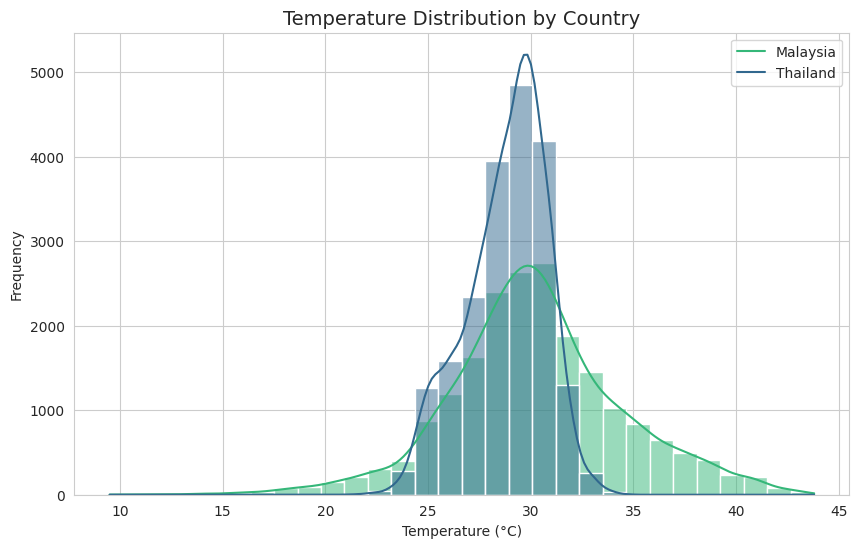

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
solar_data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/solar_data.csv")

# Convert Datetime column to datetime type
solar_data['Datetime'] = pd.to_datetime(solar_data['Datetime'], dayfirst=True)

# Extract Date and Time components for better analysis
solar_data['Date'] = solar_data['Datetime'].dt.date
solar_data['Hour'] = solar_data['Datetime'].dt.hour
solar_data['Month'] = solar_data['Datetime'].dt.month

# Define countries
countries = ['Malaysia', 'Thailand']

# Set the style for seaborn
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

# 1. Temperature Distribution by Country
plt.figure(figsize=(10, 6))
sns.histplot(data=solar_data, x='Temperature (c)', hue='Country', kde=True, bins=30, palette='viridis')
plt.title("Temperature Distribution by Country", fontsize=14)
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.legend(countries)
plt.show()

<ipython-input-11-a01e082265fb>:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=solar_data, x='Hour', y='GHI (w/m2)', hue='Country', ci=None, marker="o", palette='coolwarm')


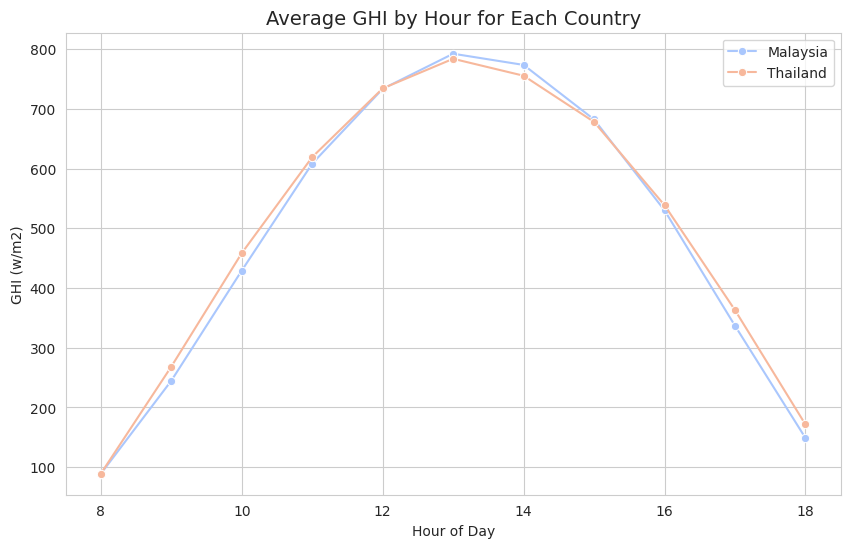

In [ ]:
# 2. Average GHI by Hour for Each Country
plt.figure(figsize=(10, 6))
sns.lineplot(data=solar_data, x='Hour', y='GHI (w/m2)', hue='Country', ci=None, marker="o", palette='coolwarm')
plt.title("Average GHI by Hour for Each Country", fontsize=14)
plt.xlabel("Hour of Day")
plt.ylabel("GHI (w/m2)")
plt.legend(countries)
plt.show()

<ipython-input-12-aa2edc8a92ec>:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=solar_data, x='Hour', y='Solar Zenith Angle (degree)', hue='Country', ci=None, marker="o", palette='plasma')


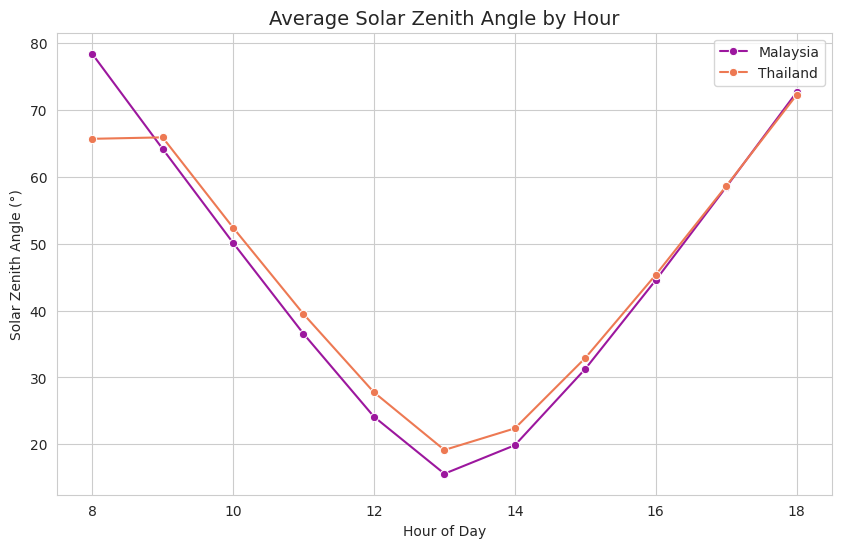

In [ ]:
# 3. Average Solar Zenith Angle by Hour
plt.figure(figsize=(10, 6))
sns.lineplot(data=solar_data, x='Hour', y='Solar Zenith Angle (degree)', hue='Country', ci=None, marker="o", palette='plasma')
plt.title("Average Solar Zenith Angle by Hour", fontsize=14)
plt.xlabel("Hour of Day")
plt.ylabel("Solar Zenith Angle (°)")
plt.legend(countries)
plt.show()

<ipython-input-13-58cbb94ae938>:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=solar_data, x='Hour', y='Wind Speed (m/s)', hue='Country', ci=None, marker="o", palette='cubehelix')


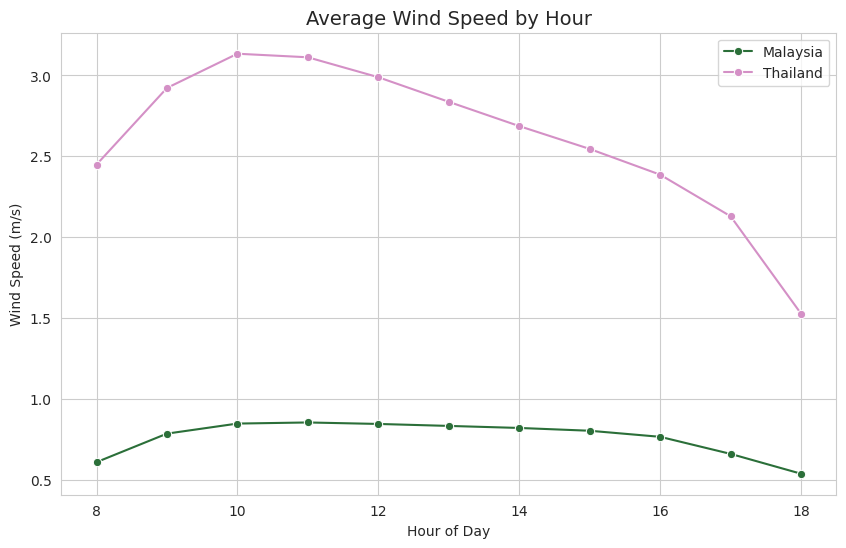

In [ ]:
# 4. Average Wind Speed by Hour
plt.figure(figsize=(10, 6))
sns.lineplot(data=solar_data, x='Hour', y='Wind Speed (m/s)', hue='Country', ci=None, marker="o", palette='cubehelix')
plt.title("Average Wind Speed by Hour", fontsize=14)
plt.xlabel("Hour of Day")
plt.ylabel("Wind Speed (m/s)")
plt.legend(countries)
plt.show()

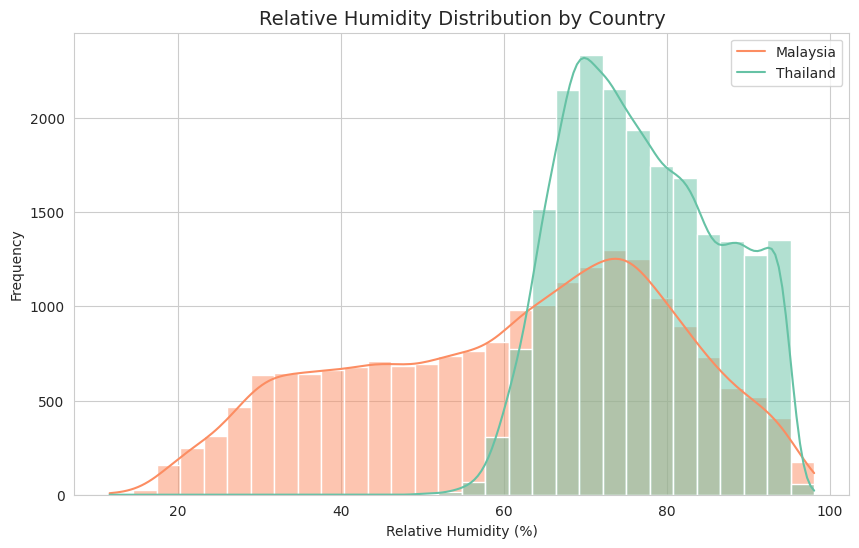

In [ ]:
# 5. Distribution of Relative Humidity
plt.figure(figsize=(10, 6))
sns.histplot(data=solar_data, x='Relative Humidity (%)', hue='Country', kde=True, bins=30, palette='Set2')
plt.title("Relative Humidity Distribution by Country", fontsize=14)
plt.xlabel("Relative Humidity (%)")
plt.ylabel("Frequency")
plt.legend(countries)
plt.show()

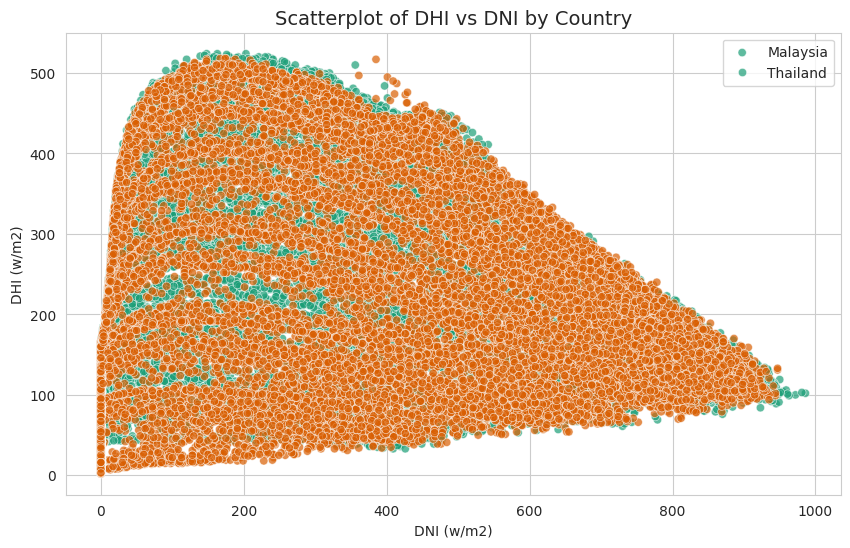

In [ ]:
# 6. Scatterplot of DHI vs DNI Colored by Country
plt.figure(figsize=(10, 6))
sns.scatterplot(data=solar_data, x='DNI (w/m2)', y='DHI (w/m2)', hue='Country', alpha=0.7, palette='Dark2')
plt.title("Scatterplot of DHI vs DNI by Country", fontsize=14)
plt.xlabel("DNI (w/m2)")
plt.ylabel("DHI (w/m2)")
plt.legend(countries)
plt.show()

<ipython-input-16-825f1bc9b08c>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=solar_data, x='Country', y='GHI (w/m2)', palette='pastel')


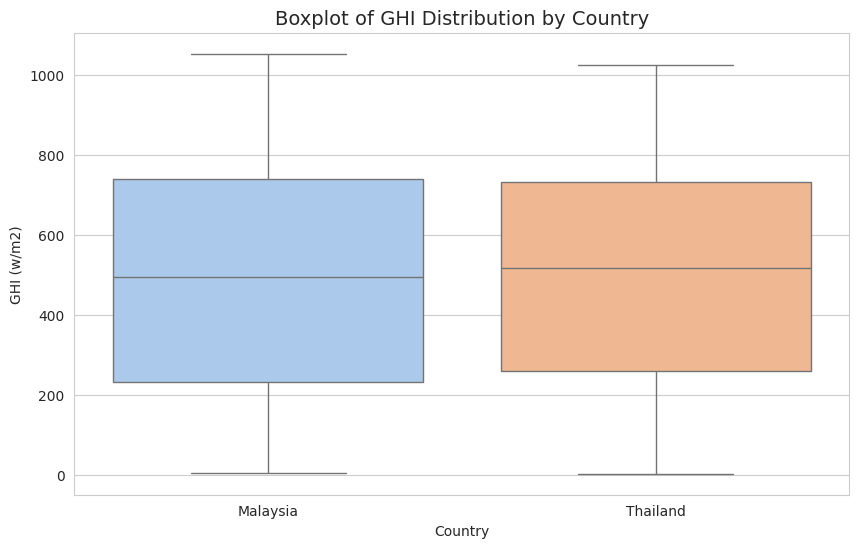

In [ ]:
# 7. Boxplot of GHI Distribution by Country
plt.figure(figsize=(10, 6))
sns.boxplot(data=solar_data, x='Country', y='GHI (w/m2)', palette='pastel')
plt.title("Boxplot of GHI Distribution by Country", fontsize=14)
plt.xlabel("Country")
plt.ylabel("GHI (w/m2)")
plt.show()

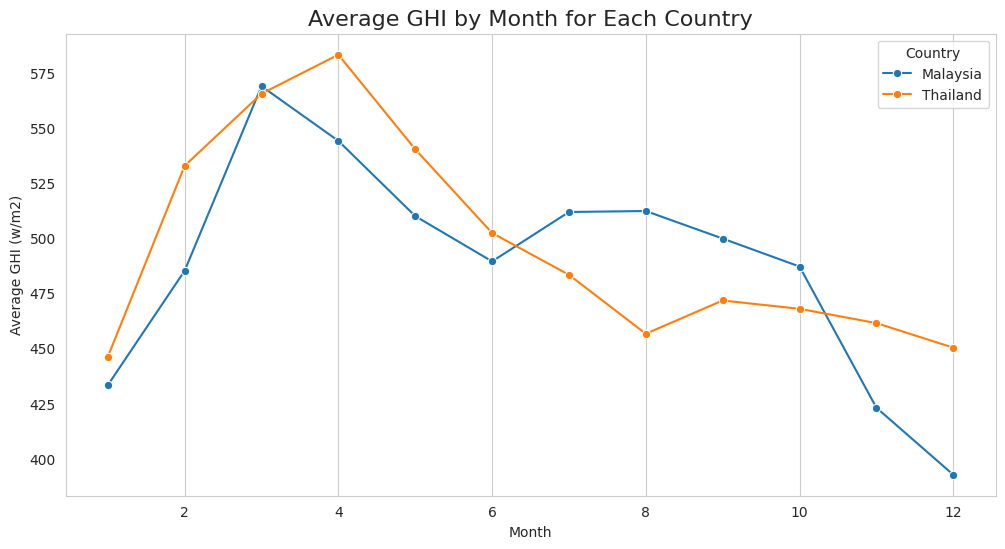

In [ ]:
# Average GHI by Month for Each Country

# Group by Month and Country to calculate average GHI
monthly_ghi = solar_data.groupby(['Country', 'Month'])['GHI (w/m2)'].mean().reset_index()

# Map month numbers to month names for better readability
monthly_ghi['Month'] = monthly_ghi['Month']

# Plotting Average GHI by Month for Each Country
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_ghi, x='Month', y='GHI (w/m2)', hue='Country', marker="o", palette='tab10')

# Chart aesthetics
plt.title("Average GHI by Month for Each Country", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Average GHI (w/m2)")
plt.legend(title="Country", loc='upper right')
plt.grid(axis='y')
plt.show()

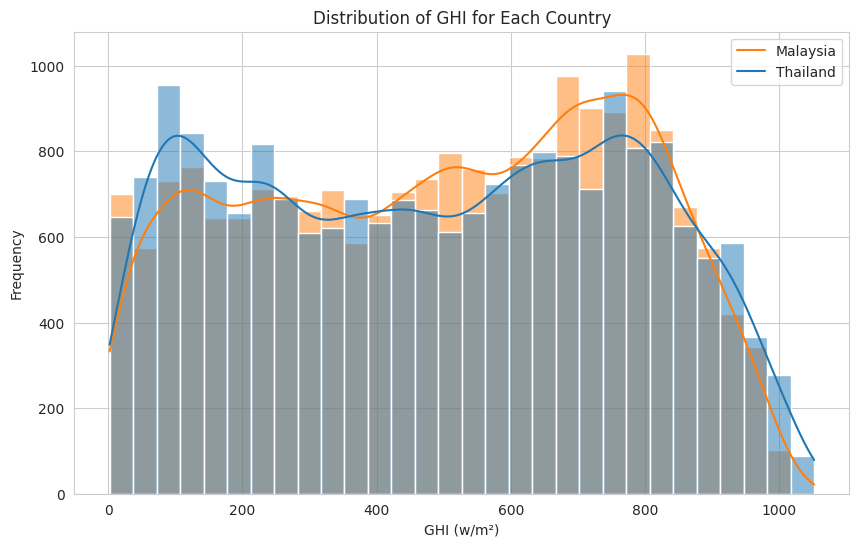

In [ ]:
# GHI Distribution by COuntry
plt.figure(figsize=(10, 6))
sns.histplot(data=solar_data, x='GHI (w/m2)', hue='Country', kde=True, bins=30)

plt.title('Distribution of GHI for Each Country')
plt.xlabel('GHI (w/m²)')
plt.ylabel('Frequency')
plt.legend(countries)
plt.grid(True)
plt.show()


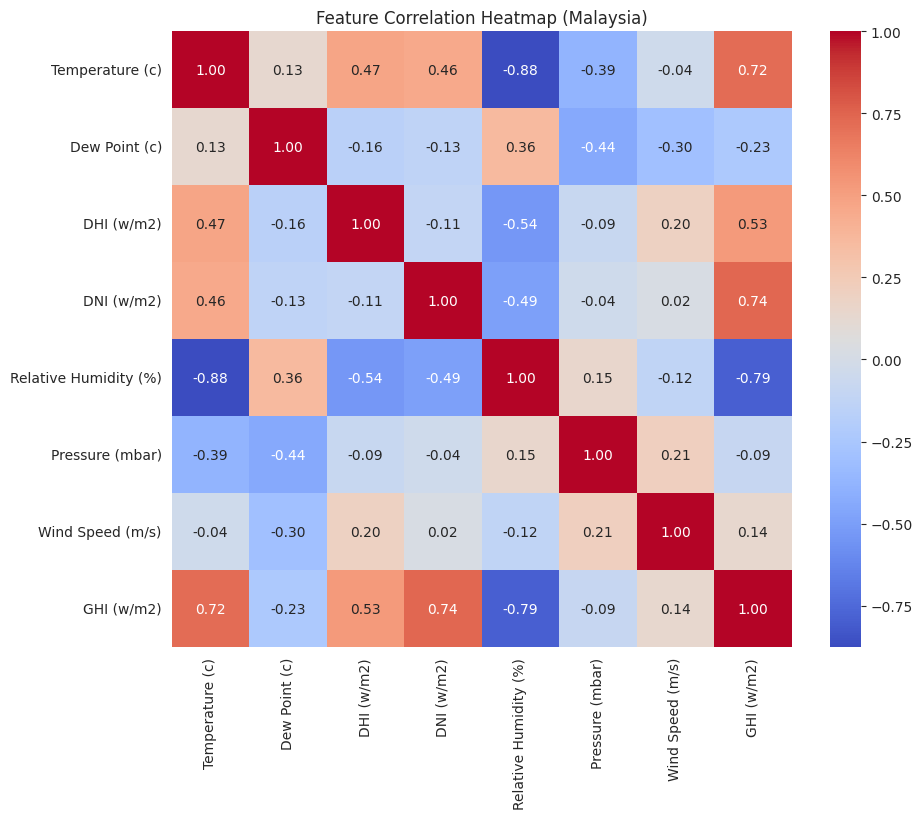

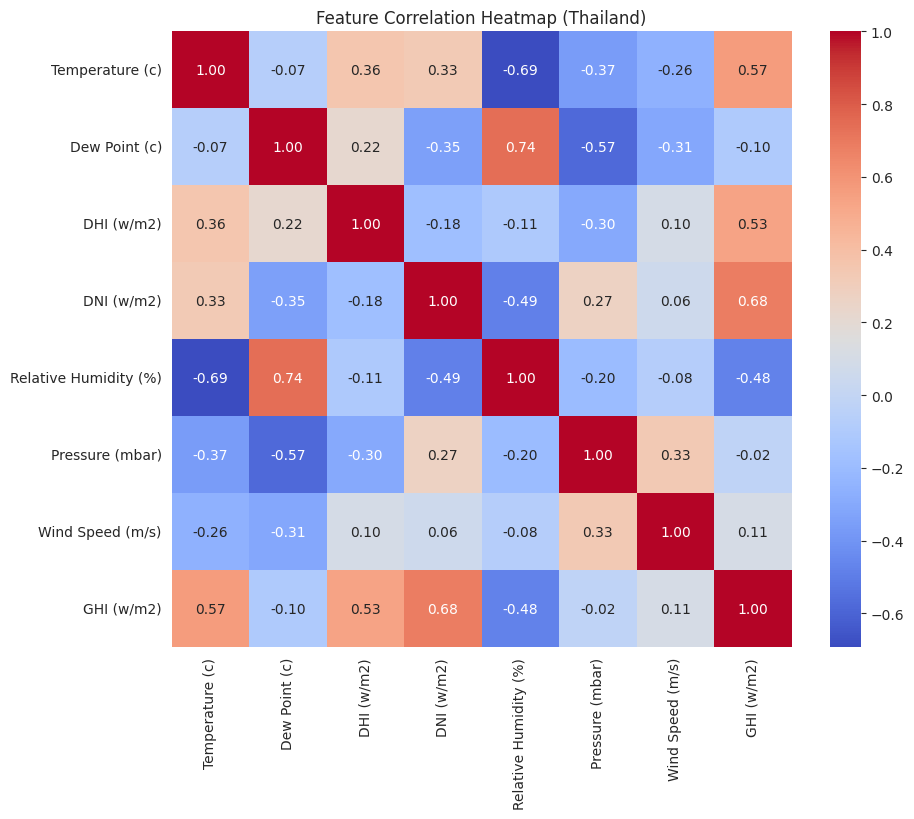

In [ ]:
# Feature Correlation HeatMap for Each Country
features = ['Temperature (c)', 'Dew Point (c)', 'DHI (w/m2)', 'DNI (w/m2)',
            'Relative Humidity (%)', 'Pressure (mbar)', 'Wind Speed (m/s)', 'GHI (w/m2)']

for country in solar_data['Country'].unique():
    country_data = solar_data[solar_data['Country'] == country]
    correlation = country_data[features].corr()

    # Plot Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
    plt.title(f'Feature Correlation Heatmap ({country})')
    plt.show()


In [ ]:
import pandas as pd

# Export to CSV files in Google Drive
malaysia_data.to_csv('/content/drive/MyDrive/malaysia_data.csv')
thailand_data.to_csv('/content/drive/MyDrive/thailand_data.csv')

In [ ]:
print("Malaysia Feature Variance:")
print(malaysia_data.var().sort_values(ascending=False))

print("\nThailand Feature Variance:")
print(thailand_data.var().sort_values(ascending=False))

Malaysia Feature Variance:
GHI (w/m2)                       81423.395287
DNI (w/m2)                       77006.118801
DHI (w/m2)                       18639.513124
Wind Direction (degrees)          9157.655036
Solar Azimuth Angle (degrees)     8571.895344
Panel Azimuth Angle (degrees)     8066.142436
Solar Zenith Angle (degree)        440.361766
Panel Tilt (degrees)               404.970513
Relative Humidity (%)               88.755826
Pressure (mbar)                      3.994397
Temperature (c)                      3.877860
Dew Point (c)                        1.037128
Precipitable Water (cm)              0.485507
Wind Speed (m/s)                     0.109831
dtype: float64

Thailand Feature Variance:
DNI (w/m2)                       75760.680871
GHI (w/m2)                       74204.902905
DHI (w/m2)                       16965.583565
Panel Azimuth Angle (degrees)     8044.401900
Wind Direction (degrees)          7158.537003
Solar Azimuth Angle (degrees)     6227.654253
Solar Zeni

<Figure size 1000x600 with 0 Axes>

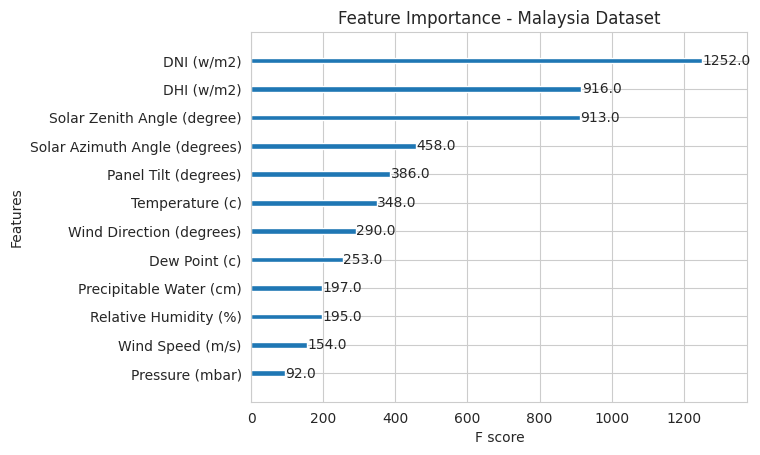

<Figure size 1000x600 with 0 Axes>

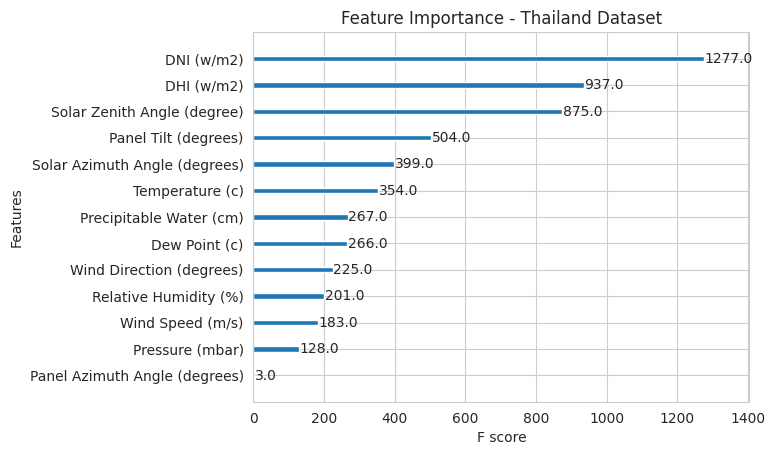

In [ ]:
# Train XGBoost model
from xgboost import XGBRegressor, plot_importance

X_malaysia = malaysia_data.drop(["GHI (w/m2)"], axis=1)
y_malaysia = malaysia_data["GHI (w/m2)"]

xgb_model = XGBRegressor()
xgb_model.fit(X_malaysia, y_malaysia)

X_thailand = thailand_data.drop(["GHI (w/m2)"], axis=1)
y_thailand = thailand_data["GHI (w/m2)"]

xgb_model_thailand = XGBRegressor()
xgb_model_thailand.fit(X_thailand, y_thailand)

# Plot feature importance
plt.figure(figsize=(10, 6))
plot_importance(xgb_model)
plt.title("Feature Importance - Malaysia Dataset")
plt.show()

plt.figure(figsize=(10, 6))
plot_importance(xgb_model_thailand)
plt.title("Feature Importance - Thailand Dataset")
plt.show()


In [ ]:
correlation_with_target_malaysia = malaysia_data.corr()["GHI (w/m2)"].sort_values(ascending=False)
correlation_with_target_thailand = thailand_data.corr()["GHI (w/m2)"].sort_values(ascending=False)

print("Malaysia Correlation with GHI:")
print(correlation_with_target_malaysia)

print("\nThailand Correlation with GHI:")
print(correlation_with_target_thailand)


Malaysia Correlation with GHI:
GHI (w/m2)                       1.000000
DNI (w/m2)                       0.742383
Temperature (c)                  0.719604
DHI (w/m2)                       0.525052
Wind Speed (m/s)                 0.140426
Panel Azimuth Angle (degrees)    0.046370
Wind Direction (degrees)         0.025706
Solar Azimuth Angle (degrees)    0.023944
Pressure (mbar)                 -0.092660
Precipitable Water (cm)         -0.134226
Dew Point (c)                   -0.233462
Panel Tilt (degrees)            -0.680944
Relative Humidity (%)           -0.791441
Solar Zenith Angle (degree)     -0.867495
Name: GHI (w/m2), dtype: float64

Thailand Correlation with GHI:
GHI (w/m2)                       1.000000
DNI (w/m2)                       0.684404
Temperature (c)                  0.565859
DHI (w/m2)                       0.534155
Wind Speed (m/s)                 0.105013
Wind Direction (degrees)         0.090902
Solar Azimuth Angle (degrees)    0.050411
Panel Azimuth Angle (d

In [ ]:
from sklearn.feature_selection import mutual_info_regression

X = malaysia_data.drop(columns=["GHI (w/m2)"])
y = malaysia_data["GHI (w/m2)"]
mutual_info = mutual_info_regression(X, y)
feature_scores = pd.Series(mutual_info, index=X.columns).sort_values(ascending=False)
print("Feature Importance (Mutual Information):")
print(feature_scores)


Feature Importance (Mutual Information):
DHI (w/m2)                       1.302703
Solar Zenith Angle (degree)      0.974039
DNI (w/m2)                       0.897043
Panel Tilt (degrees)             0.759107
Relative Humidity (%)            0.491245
Temperature (c)                  0.395114
Solar Azimuth Angle (degrees)    0.384937
Dew Point (c)                    0.067675
Pressure (mbar)                  0.034188
Wind Speed (m/s)                 0.028270
Precipitable Water (cm)          0.027706
Wind Direction (degrees)         0.021602
Panel Azimuth Angle (degrees)    0.016950
dtype: float64


In [ ]:
#Split data into train, test and valid
from sklearn.model_selection import train_test_split

# Select important features
important_features = ['DNI (w/m2)','DHI (w/m2)' ,'Temperature (c)', 'Relative Humidity (%)',
                      'Wind Speed (m/s)', 'Precipitable Water (cm)']
target = 'GHI (w/m2)'

# Prepare data for Malaysia
X_malaysia = malaysia_data[important_features]
y_malaysia = malaysia_data[target]

# Prepare data for Thailand
X_thailand = thailand_data[important_features]
y_thailand = thailand_data[target]

from sklearn.model_selection import train_test_split

# Assuming X_malaysia, y_malaysia, X_thailand, y_thailand are already defined datasets

# Split Malaysia data: Train (70%), Test (30%)
X_train_my, X_test_my, y_train_my, y_test_my = train_test_split(X_malaysia, y_malaysia, test_size=0.3, random_state=42)

# Split Thailand data: Train (70%), Test (30%)
X_train_th, X_test_th, y_train_th, y_test_th = train_test_split(X_thailand, y_thailand, test_size=0.3, random_state=42)

# Display data sizes
malaysia_splits = {
    "Training": X_train_my.shape,
    "Testing": X_test_my.shape
}

thailand_splits = {
    "Training": X_train_th.shape,
    "Testing": X_test_th.shape
}

malaysia_splits, thailand_splits

({'Training': (14067, 6), 'Testing': (6030, 6)},
 {'Training': (14067, 6), 'Testing': (6030, 6)})

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the Min-Max Scaler
scaler = MinMaxScaler()

# Normalize Malaysia data
X_train_my = scaler.fit_transform(X_train_my)  # Fit and transform on training data
X_test_my = scaler.transform(X_test_my)  # Transform test data using the same scaler

# Normalize Thailand data
X_train_th = scaler.fit_transform(X_train_th)  # Fit and transform on training data
X_test_th = scaler.transform(X_test_th)  # Transform test data using the same scaler

# Display normalized data sizes (same as original since scaling doesn't change shape)
malaysia_scaled_splits = {
    "Training (Scaled)": X_train_my.shape,
    "Testing (Scaled)": X_test_my.shape
}

thailand_scaled_splits = {
    "Training (Scaled)": X_train_th.shape,
    "Testing (Scaled)": X_test_th.shape
}

malaysia_scaled_splits, thailand_scaled_splits


({'Training (Scaled)': (14067, 6), 'Testing (Scaled)': (6030, 6)},
 {'Training (Scaled)': (14067, 6), 'Testing (Scaled)': (6030, 6)})

In [ ]:
import joblib

# Save the scaler to a pkl file
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!cp scaler.pkl /content/drive/My\ Drive/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Check if the scaler has been properly fitted
def check_scaler(scaler, X_train, dataset_name):
    if hasattr(scaler, 'data_min_') and hasattr(scaler, 'data_max_'):
        print(f"\nScaler for {dataset_name} has been fitted.")
        print(f"Feature-wise Minimums: {scaler.data_min_}")
        print(f"Feature-wise Maximums: {scaler.data_max_}")
    else:
        print(f"\nScaler for {dataset_name} has NOT been fitted.")

    # Scale the training data
    X_train_scaled = scaler.transform(X_train)

    # Display raw and scaled samples
    print(f"\n{dataset_name} - Raw Training Data (First 5 Samples):")
    print(X_train[:5])  # Raw data

    print(f"\n{dataset_name} - Scaled Training Data (First 5 Samples):")
    print(X_train_scaled[:5])  # Scaled data

    # Reverse the scaling to verify consistency
    X_train_reversed = scaler.inverse_transform(X_train_scaled)
    print(f"\n{dataset_name} - Reversed Scaled Training Data (First 5 Samples):")
    print(X_train_reversed[:5])  # Reversed data

# Check scaler for Malaysia
check_scaler(scaler, X_train_my, "Malaysia")


check_scaler(scaler, X_train_th, "Thailand")



Scaler for Malaysia has been fitted.
Feature-wise Minimums: [ 0.    2.    9.5  11.59  0.2   0.9 ]
Feature-wise Maximums: [947.   518.    43.7   97.74   8.4    7.5 ]

Malaysia - Raw Training Data (First 5 Samples):
[[0.42494929 0.37957611 0.4379562  0.7545276  0.27272727 0.7962963 ]
 [0.74239351 0.22543353 0.45255474 0.74863626 0.86363636 0.51851852]
 [0.28803245 0.68015414 0.58394161 0.47392538 0.45454545 0.55555556]
 [0.79817444 0.26396917 0.67883212 0.50360026 0.5        0.7037037 ]
 [0.05578093 0.15606936 0.27737226 0.95941523 0.31818182 0.66666667]]

Malaysia - Scaled Training Data (First 5 Samples):
[[ 4.48732091e-04 -3.14035638e-03 -2.64972041e-01 -1.25774491e-01
   8.86917960e-03 -1.57126824e-02]
 [ 7.83942459e-04 -3.43908231e-03 -2.64545183e-01 -1.25842876e-01
   8.09312639e-02 -5.78002245e-02]
 [ 3.04152539e-04 -2.55784081e-03 -2.60703462e-01 -1.29031627e-01
   3.10421286e-02 -5.21885522e-02]
 [ 8.42845240e-04 -3.36440083e-03 -2.57928885e-01 -1.28687170e-01
   3.65853659e-02 

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [ ]:
# Function to evaluate model performance
def evaluate_model(y_true, y_pred, dataset_name, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{dataset_name} {model_name} Performance:")
    print(f"RMSE: {rmse:.6f}")
    print(f"MAE: {mae:.6f}")
    print(f"R²: {r2:.6f}")

    return {"RMSE": rmse, "MAE": mae, "R²": r2}


Training SVR for Malaysia 

Malaysia SVR Performance:
RMSE: 49.584850
MAE: 31.569183
R²: 0.969690

Training SVR for Thailand 

Thailand SVR Performance:
RMSE: 58.693811
MAE: 39.333669
R²: 0.953870


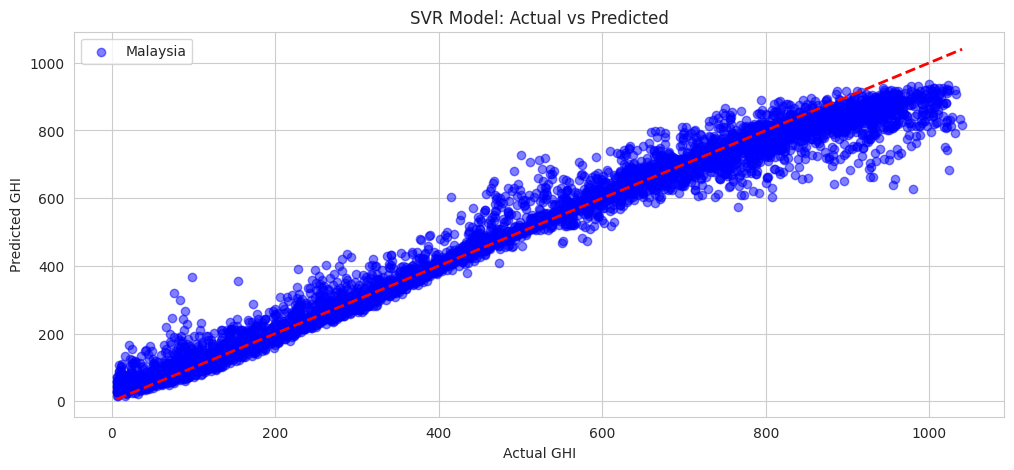

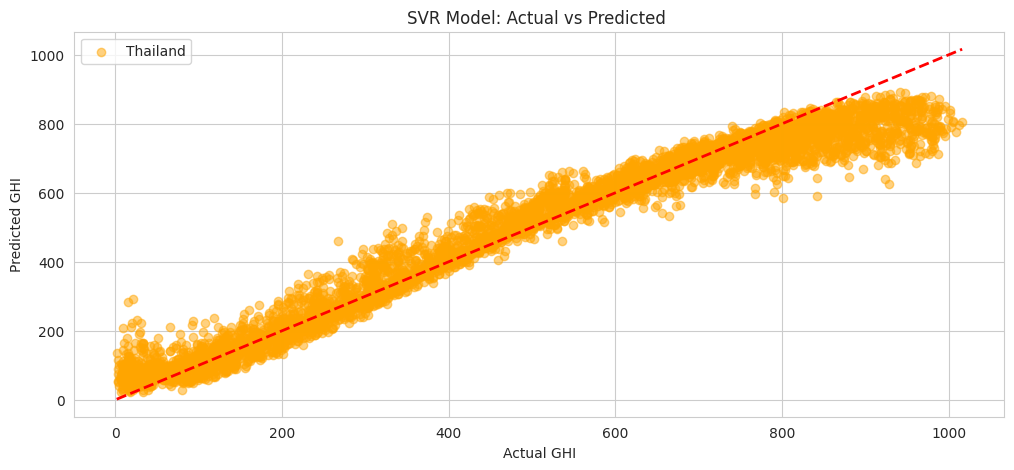

In [ ]:
#SVR Model
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# ==================== SVR for Malaysia  ====================
print("\nTraining SVR for Malaysia ")
svr_my = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr_my.fit(X_train_my, y_train_my)

# Predict on test set
y_pred_test_my = svr_my.predict(X_test_my)

# Evaluate SVR for Malaysia
svr_metrics_my = evaluate_model(y_test_my, y_pred_test_my, "Malaysia", "SVR")

# ==================== SVR for Thailand  ====================
print("\nTraining SVR for Thailand ")
svr_th = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr_th.fit(X_train_th, y_train_th)

# Predict on test set
y_pred_test_th = svr_th.predict(X_test_th)

# Evaluate SVR for Thailand
svr_metrics_th = evaluate_model(y_test_th, y_pred_test_th, "Thailand", "SVR")

# ==================== Visualization of Results (Using Test Set) ====================
# Malaysia: Actual vs Predicted
plt.figure(figsize=(12, 5))
plt.scatter(y_test_my, y_pred_test_my, alpha=0.5, label="Malaysia", color="blue")
plt.plot([y_test_my.min(), y_test_my.max()], [y_test_my.min(), y_test_my.max()], 'r--', lw=2)
plt.xlabel('Actual GHI')
plt.ylabel('Predicted GHI')
plt.title('SVR Model: Actual vs Predicted')
plt.legend()
plt.show()

# Thailand: Actual vs Predicted
plt.figure(figsize=(12, 5))
plt.scatter(y_test_th, y_pred_test_th, alpha=0.5, label="Thailand", color="orange")
plt.plot([y_test_th.min(), y_test_th.max()], [y_test_th.min(), y_test_th.max()], 'r--', lw=2)
plt.xlabel('Actual GHI')
plt.ylabel('Predicted GHI')
plt.title('SVR Model: Actual vs Predicted ')
plt.legend()
plt.show()




Training XGBoost for Malaysia...

Malaysia XGBoost Performance:
RMSE: 17.002107
MAE: 10.349645
R²: 0.996436

Training XGBoost for Thailand...

Thailand XGBoost Performance:
RMSE: 13.765956
MAE: 9.000223
R²: 0.997462


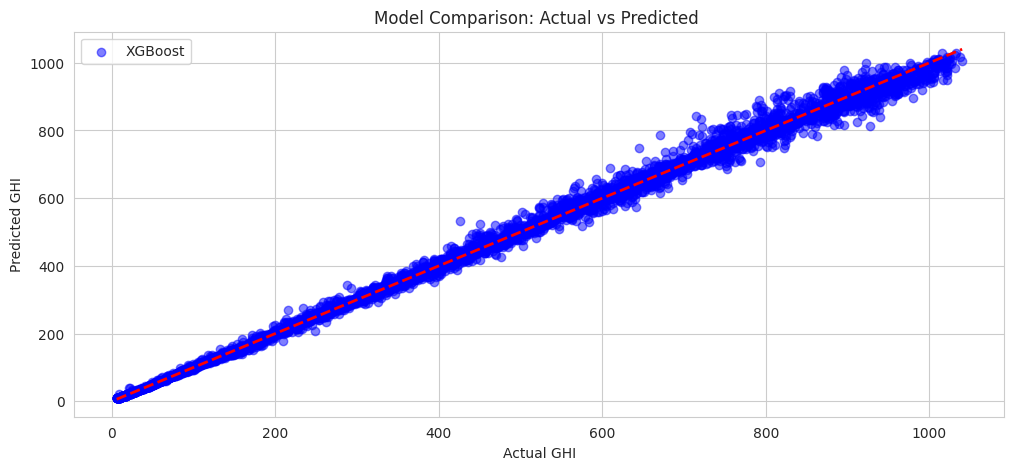

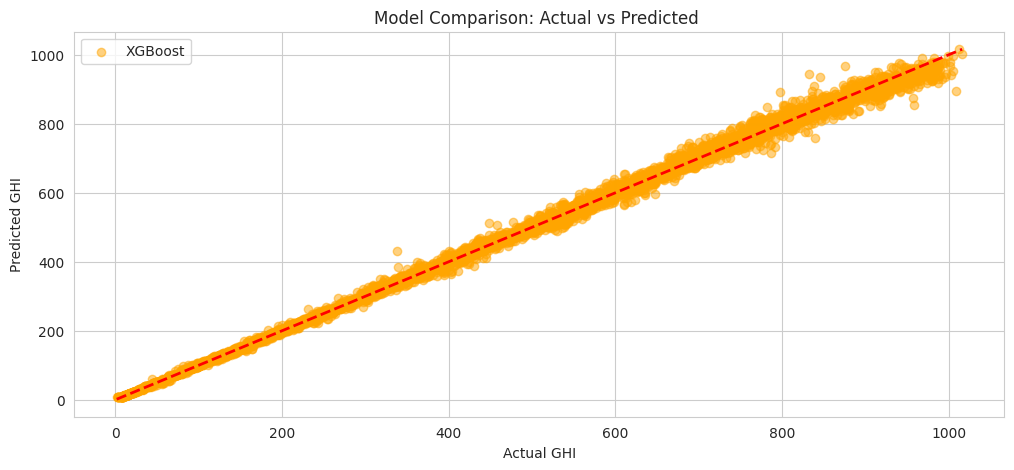

In [ ]:
#XGBoost Regressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# ==================== XGBoost for Malaysia ====================
print("\nTraining XGBoost for Malaysia...")
xgb_my = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
xgb_my.fit(X_train_my, y_train_my)

# Predict on test set
y_pred_test_my_xgb = xgb_my.predict(X_test_my)

# Evaluate XGBoost for Malaysia
xgb_metrics_my = evaluate_model(y_test_my, y_pred_test_my_xgb, "Malaysia", "XGBoost")

# ==================== XGBoost for Thailand ====================
print("\nTraining XGBoost for Thailand...")
xgb_th = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
xgb_th.fit(X_train_th, y_train_th)

# Predict on test set
y_pred_test_th_xgb = xgb_th.predict(X_test_th)

# Evaluate XGBoost for Thailand
xgb_metrics_th = evaluate_model(y_test_th, y_pred_test_th_xgb, "Thailand", "XGBoost")

# ==================== Visualization of Results ====================
# Malaysia: Actual vs Predicted
plt.figure(figsize=(12, 5))
plt.scatter(y_test_my, y_pred_test_my_xgb, alpha=0.5, label="XGBoost", color="blue")
plt.plot([y_test_my.min(), y_test_my.max()], [y_test_my.min(), y_test_my.max()], 'r--', lw=2)
plt.xlabel('Actual GHI')
plt.ylabel('Predicted GHI')
plt.title('Model Comparison: Actual vs Predicted ')
plt.legend()
plt.show()

# Thailand: Actual vs Predicted
plt.figure(figsize=(12, 5))
plt.scatter(y_test_th, y_pred_test_th_xgb, alpha=0.5, label="XGBoost", color="orange")
plt.plot([y_test_th.min(), y_test_th.max()], [y_test_th.min(), y_test_th.max()], 'r--', lw=2)
plt.xlabel('Actual GHI')
plt.ylabel('Predicted GHI')
plt.title('Model Comparison: Actual vs Predicted ')
plt.legend()
plt.show()


Training Random Forest for Malaysia...

Malaysia Random Forest Performance:
RMSE: 15.437254
MAE: 8.122602
R²: 0.997062

Training Random Forest for Thailand...

Thailand Random Forest Performance:
RMSE: 13.403682
MAE: 7.942499
R²: 0.997594


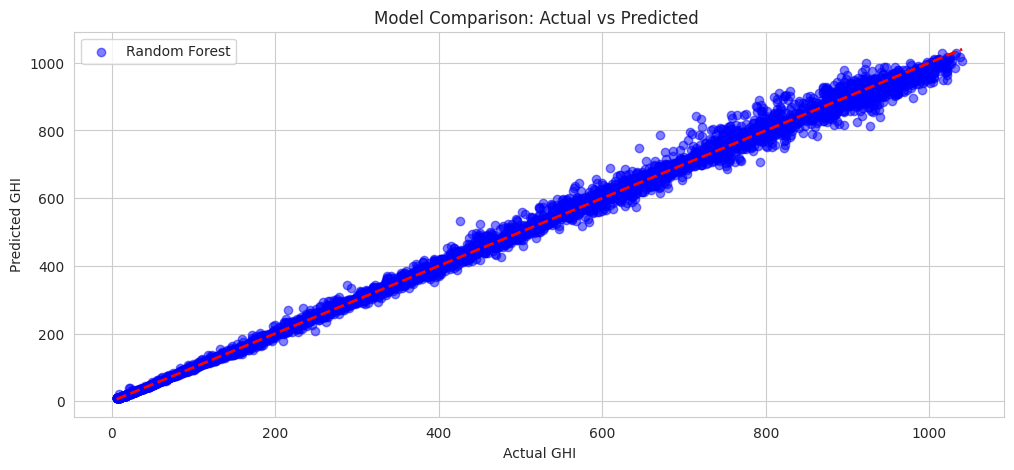

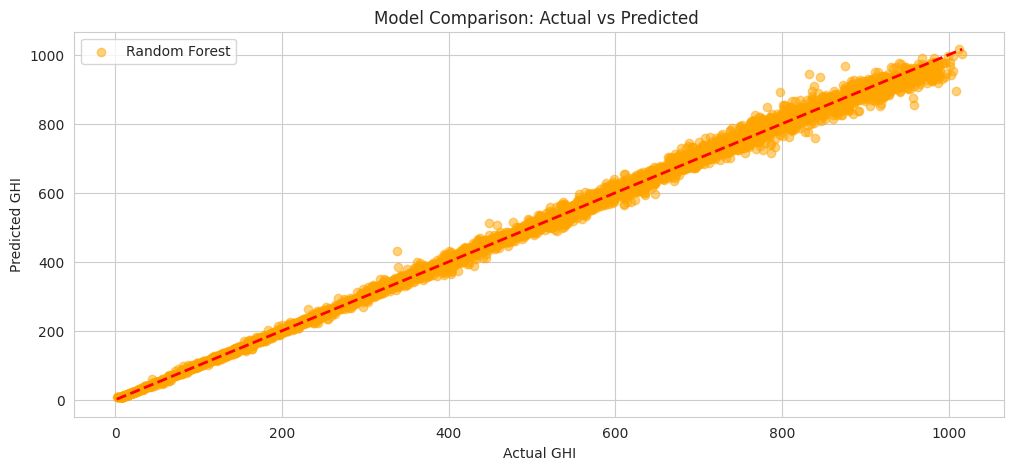

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# ==================== Random Forest for Malaysia ====================
print("\nTraining Random Forest for Malaysia...")
rf_my = RandomForestRegressor(n_estimators=100, random_state=42)
rf_my.fit(X_train_my, y_train_my)

# Predict on test set
y_pred_test_my_rf = rf_my.predict(X_test_my)

# Evaluate Random Forest for Malaysia
rf_metrics_my = evaluate_model(y_test_my, y_pred_test_my_rf, "Malaysia", "Random Forest")

# ==================== Random Forest for Thailand ====================
print("\nTraining Random Forest for Thailand...")
rf_th = RandomForestRegressor(n_estimators=100, random_state=42)
rf_th.fit(X_train_th, y_train_th)

# Predict on test set
y_pred_test_th_rf = rf_th.predict(X_test_th)

# Evaluate Random Forest for Thailand
rf_metrics_th = evaluate_model(y_test_th, y_pred_test_th_rf, "Thailand", "Random Forest")

# ==================== Visualization of Results ====================
# Malaysia: Actual vs Predicted
plt.figure(figsize=(12, 5))
plt.scatter(y_test_my, y_pred_test_my_xgb, alpha=0.5, label="Random Forest", color="blue")
plt.plot([y_test_my.min(), y_test_my.max()], [y_test_my.min(), y_test_my.max()], 'r--', lw=2)
plt.xlabel('Actual GHI')
plt.ylabel('Predicted GHI')
plt.title('Model Comparison: Actual vs Predicted ')
plt.legend()
plt.show()

# Thailand: Actual vs Predicted
plt.figure(figsize=(12, 5))
plt.scatter(y_test_th, y_pred_test_th_xgb, alpha=0.5, label="Random Forest", color="orange")
plt.plot([y_test_th.min(), y_test_th.max()], [y_test_th.min(), y_test_th.max()], 'r--', lw=2)
plt.xlabel('Actual GHI')
plt.ylabel('Predicted GHI')
plt.title('Model Comparison: Actual vs Predicted ')
plt.legend()
plt.show()


Training Decision Tree for Malaysia

Malaysia Decision Tree Performance:
RMSE: 27.424206
MAE: 16.871295
R²: 0.990728

Training Decision Tree for Thailand

Thailand Decision Tree Performance:
RMSE: 25.951823
MAE: 16.467232
R²: 0.990981


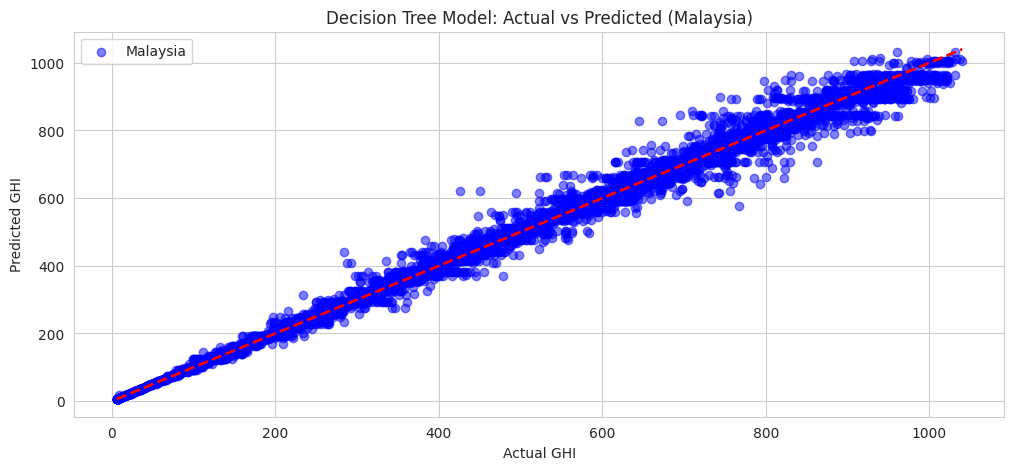

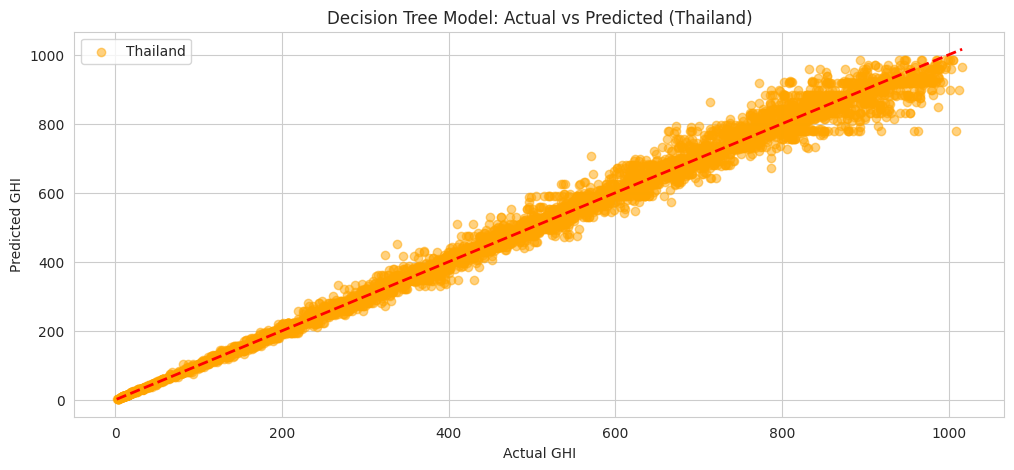

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# ==================== Decision Tree for Malaysia ====================
print("\nTraining Decision Tree for Malaysia")
dt_my = DecisionTreeRegressor(random_state=42, max_depth=10)  # Example hyperparameters
dt_my.fit(X_train_my, y_train_my)

# Predict on test set
y_pred_test_my_dt = dt_my.predict(X_test_my)

# Evaluate Decision Tree for Malaysia
dt_metrics_my = evaluate_model(y_test_my, y_pred_test_my_dt, "Malaysia", "Decision Tree")

# ==================== Decision Tree for Thailand ====================
print("\nTraining Decision Tree for Thailand")
dt_th = DecisionTreeRegressor(random_state=42, max_depth=10)  # Example hyperparameters
dt_th.fit(X_train_th, y_train_th)

# Predict on test set
y_pred_test_th_dt = dt_th.predict(X_test_th)

# Evaluate Decision Tree for Thailand
dt_metrics_th = evaluate_model(y_test_th, y_pred_test_th_dt, "Thailand", "Decision Tree")

# ==================== Visualization of Results (Using Test Set) ====================
# Malaysia: Actual vs Predicted
plt.figure(figsize=(12, 5))
plt.scatter(y_test_my, y_pred_test_my_dt, alpha=0.5, label="Malaysia", color="blue")
plt.plot([y_test_my.min(), y_test_my.max()], [y_test_my.min(), y_test_my.max()], 'r--', lw=2)
plt.xlabel('Actual GHI')
plt.ylabel('Predicted GHI')
plt.title('Decision Tree Model: Actual vs Predicted (Malaysia)')
plt.legend()
plt.show()

# Thailand: Actual vs Predicted
plt.figure(figsize=(12, 5))
plt.scatter(y_test_th, y_pred_test_th_dt, alpha=0.5, label="Thailand", color="orange")
plt.plot([y_test_th.min(), y_test_th.max()], [y_test_th.min(), y_test_th.max()], 'r--', lw=2)
plt.xlabel('Actual GHI')
plt.ylabel('Predicted GHI')
plt.title('Decision Tree Model: Actual vs Predicted (Thailand)')
plt.legend()
plt.show()


In [ ]:
# Combine all performance metrics for comparison
comparison_table = {
    "Model": ["SVR", "XGBoost", "Random Forest", "Decision Tree"],
    "Malaysia RMSE": [
        svr_metrics_my["RMSE"],
        xgb_metrics_my["RMSE"],
        rf_metrics_my["RMSE"],
        dt_metrics_my["RMSE"]
    ],
    "Malaysia MAE": [
        svr_metrics_my["MAE"],
        xgb_metrics_my["MAE"],
        rf_metrics_my["MAE"],
        dt_metrics_my["MAE"]
    ],
    "Malaysia R²": [
        svr_metrics_my["R²"],
        xgb_metrics_my["R²"],
        rf_metrics_my["R²"],
        dt_metrics_my["R²"]
    ],
    "Thailand RMSE": [
        svr_metrics_th["RMSE"],
        xgb_metrics_th["RMSE"],
        rf_metrics_th["RMSE"],
        dt_metrics_th["RMSE"]
    ],
    "Thailand MAE": [
        svr_metrics_th["MAE"],
        xgb_metrics_th["MAE"],
        rf_metrics_th["MAE"],
        dt_metrics_th["MAE"]
    ],
    "Thailand R²": [
        svr_metrics_th["R²"],
        xgb_metrics_th["R²"],
        rf_metrics_th["R²"],
        dt_metrics_th["R²"]
    ],
}

# Print the comparison table
print("\nModel Performance Comparison:")
print(f"{'Model':<15}{'Malaysia RMSE':<15}{'Malaysia MAE':<15}{'Malaysia R²':<15}"
      f"{'Thailand RMSE':<15}{'Thailand MAE':<15}{'Thailand R²':<15}")
print("-" * 90)

for i in range(len(comparison_table["Model"])):
    print(f"{comparison_table['Model'][i]:<15}"
          f"{comparison_table['Malaysia RMSE'][i]:<15.4f}"
          f"{comparison_table['Malaysia MAE'][i]:<15.4f}"
          f"{comparison_table['Malaysia R²'][i]:<15.4f}"
          f"{comparison_table['Thailand RMSE'][i]:<15.4f}"
          f"{comparison_table['Thailand MAE'][i]:<15.4f}"
          f"{comparison_table['Thailand R²'][i]:<15.4f}")



Model Performance Comparison:
Model          Malaysia RMSE  Malaysia MAE   Malaysia R²    Thailand RMSE  Thailand MAE   Thailand R²    
------------------------------------------------------------------------------------------
SVR            49.5849        31.5692        0.9697         58.6938        39.3337        0.9539         
XGBoost        17.0021        10.3496        0.9964         13.7660        9.0002         0.9975         
Random Forest  15.4373        8.1226         0.9971         13.4037        7.9425         0.9976         
Decision Tree  27.4242        16.8713        0.9907         25.9518        16.4672        0.9910         


In [ ]:
# Determine the best performing model based on RMSE (primary metric), MAE, and R²

# List of models and their metrics
models = ["SVR", "XGBoost", "Random Forest", "Decision Tree"]
metrics_my = [
    svr_metrics_my, xgb_metrics_my, rf_metrics_my, dt_metrics_my
]
metrics_th = [
    svr_metrics_th, xgb_metrics_th, rf_metrics_th, dt_metrics_th
]

# Function to find the best model for a dataset
def find_best_model(metrics, dataset_name):
    # Sorting by RMSE, then MAE (if RMSE is tied), and then R² in descending order
    best_model_index = sorted(
        range(len(metrics)),
        key=lambda i: (metrics[i]["RMSE"], metrics[i]["MAE"], -metrics[i]["R²"])
    )[0]
    best_model_name = models[best_model_index]
    print(f"\nBest Model for {dataset_name}: {best_model_name}")
    print(f"Metrics: RMSE = {metrics[best_model_index]['RMSE']:.4f}, "
          f"MAE = {metrics[best_model_index]['MAE']:.4f}, "
          f"R² = {metrics[best_model_index]['R²']:.4f}")
    return best_model_name

# Find best models
best_model_my = find_best_model(metrics_my, "Malaysia")
best_model_th = find_best_model(metrics_th, "Thailand")



Best Model for Malaysia: Random Forest
Metrics: RMSE = 15.4373, MAE = 8.1226, R² = 0.9971

Best Model for Thailand: Random Forest
Metrics: RMSE = 13.4037, MAE = 7.9425, R² = 0.9976


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Hyperparameter Tuning for Random Forest (Malaysia)
print("\nTuning Random Forest for Malaysia...")
rf = RandomForestRegressor(random_state=42)
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}
rf_grid_search = GridSearchCV(estimator=rf, param_grid=rf_param_grid, scoring='neg_mean_squared_error', cv=3, verbose=1)
rf_grid_search.fit(X_train_my, y_train_my)

# Get best parameters and retrain the model
rf_best_params = rf_grid_search.best_params_
rf_best_model = RandomForestRegressor(**rf_best_params, random_state=42)
rf_best_model.fit(X_train_my, y_train_my)
y_pred_rf_best = rf_best_model.predict(X_test_my)

# Metrics for tuned Random Forest
rf_best_metrics = evaluate_model(y_test_my, y_pred_rf_best, "Malaysia", "Tuned Random Forest")


Tuning Random Forest for Malaysia...
Fitting 3 folds for each of 36 candidates, totalling 108 fits

Malaysia Tuned Random Forest Performance:
RMSE: 15.310646
MAE: 8.052071
R²: 0.997110


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Hyperparameter Tuning for Random Forest (Thailand)
print("\nTuning Random Forest for Thailand...")
rf = RandomForestRegressor(random_state=42)
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}
rf_grid_search = GridSearchCV(estimator=rf, param_grid=rf_param_grid, scoring='neg_mean_squared_error', cv=3, verbose=1)
rf_grid_search.fit(X_train_th, y_train_th)

# Get best parameters and retrain the model
rf_best_th_params = rf_grid_search.best_params_
rf_best_th_model = RandomForestRegressor(**rf_best_th_params, random_state=42)
rf_best_th_model.fit(X_train_th, y_train_th)
y_pred_rf_th_best = rf_best_th_model.predict(X_test_th)

# Metrics for tuned Random Forest
rf_best_th_metrics = evaluate_model(y_test_th, y_pred_rf_th_best, "Thailand", "Tuned Random Forest")


Tuning Random Forest for Thailand...
Fitting 3 folds for each of 36 candidates, totalling 108 fits

Thailand Tuned Random Forest Performance:
RMSE: 13.312352
MAE: 7.889065
R²: 0.997627


In [ ]:
# Comparison of Base Model and Tuned Model Metrics
print("\nComparison of Base and Tuned Model Metrics:")
print(f"{'Model':<20}{'Dataset':<10}{'RMSE':<10}{'MAE':<10}{'R²':<10}")
print(f"{'-' * 50}")
print(f"{'Base Random Forest':<20}{'Malaysia':<10}{rf_metrics_my['RMSE']:<10.4f}{rf_metrics_my['MAE']:<10.4f}{rf_metrics_my['R²']:<10.4f}")
print(f"{'Tuned Random Forest':<20}{'Malaysia':<10}{rf_best_metrics['RMSE']:<10.4f}{rf_best_metrics['MAE']:<10.4f}{rf_best_metrics['R²']:<10.4f}")
print(f"{'Base Random Forest':<20}{'Thailand':<10}{rf_metrics_th['RMSE']:<10.4f}{rf_metrics_th['MAE']:<10.4f}{rf_metrics_th['R²']:<10.4f}")
print(f"{'Tuned Random Forest':<20}{'Thailand':<10}{rf_best_th_metrics['RMSE']:<10.4f}{rf_best_th_metrics['MAE']:<10.4f}{rf_best_th_metrics['R²']:<10.4f}")


Comparison of Base and Tuned Model Metrics:
Model               Dataset   RMSE      MAE       R²        
--------------------------------------------------
Base Random Forest  Malaysia  15.4373   8.1226    0.9971    
Tuned Random Forest Malaysia  15.3106   8.0521    0.9971    
Base Random Forest  Thailand  13.4037   7.9425    0.9976    
Tuned Random Forest Thailand  13.3124   7.8891    0.9976    


In [ ]:
# Define the prediction function
def predict_ghi_best_model(country, dni, dhi, temperature, humidity, wind_speed, precipitable_water):
    # Prepare input data
    input_data = [[dni, dhi, temperature, humidity, wind_speed, precipitable_water]]
    input_data = scaler.transform(input_data)  # Apply the scaler used during training

    # Predict using the best model
    if country.lower() == "malaysia":
        prediction = rf_best_model.predict(input_data)
        return prediction[0]
    elif country.lower() == "thailand":
        prediction = rf_best_th_model.predict(input_data)
        return prediction[0]
    else:
        raise ValueError("Country must be either 'Malaysia' or 'Thailand'.")

# Example Test Predictions
malaysia_test = predict_ghi_best_model("Malaysia", dni=400, dhi=400, temperature=25, humidity=70, wind_speed=2, precipitable_water=1.3)
thailand_test = predict_ghi_best_model("Thailand", dni=400, dhi=400, temperature=25, humidity=70, wind_speed=2, precipitable_water=1.3)

malaysia_test, thailand_test


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


(795.17, 767.365)

In [ ]:
import joblib
# Save the tuned Random Forest model for Malaysia
rf_best_model_my_filename = "tuned_random_forest_malaysia.pkl"
joblib.dump(rf_best_model, rf_best_model_my_filename)
print(f"Tuned Random Forest model for Malaysia saved as {rf_best_model_my_filename}")

# Save the tuned Random Forest model for Thailand
rf_best_model_th_filename = "tuned_random_forest_thailand.pkl"
joblib.dump(rf_best_th_model, rf_best_model_th_filename)
print(f"Tuned XGBoost model for Thailand saved as {rf_best_model_th_filename}")

Tuned Random Forest model for Malaysia saved as tuned_random_forest_malaysia.pkl
Tuned XGBoost model for Thailand saved as tuned_random_forest_thailand.pkl


In [ ]:
 # export the tuned_random_forest_malaysia.pkl and tuned_random_forest_thailand.pkl file to google drive

drive.mount('/content/drive')

!cp tuned_random_forest_malaysia.pkl /content/drive/MyDrive/
!cp tuned_random_forest_thailand.pkl /content/drive/MyDrive/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
